In [91]:
import numpy as np 
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt                               
import os 
import matplotlib.colors as mcolors
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.gridspec as gridspec
matplotlib.rcParams["figure.dpi"] = 150
from particle import PDGID

In [92]:
datadir = './Simulation_Output_Eliza/'
# datadir = './SimOutput_new/'
# datadir = './SimOutput_0716_1/'
flp = 0
trackDir = '/local/d1/smartpixML/reGenBIB/produceSmartPixMuC/Tracklists0716/BIB_tracklists/'
trackDir = '/local/d1/smartpixML/reGenBIB/produceSmartPixMuC/Tracklists0716_1/BIB_tracklists/'
trackDir = '/home/dabadjiev/smartpixels_ml_dsabadjiev/smartpixML/reGenBIB/MuonColliderSim/Tracklists/BIB_tracklists/'
trackHeader = ["cota", "cotb", "p", "flp", "ylocal", "zglobal", "pt", "t", "hit_pdg"]
# data = pd.read_csv('.BIB_tracklist0.txt',sep=' ',header=None,names=trackHeader)


In [93]:
truthbib = pd.DataFrame()
recon2Dbib = pd.DataFrame()
truthsig = pd.DataFrame()
recon2Dsig = pd.DataFrame()
trackData = pd.DataFrame()

for file in os.listdir(datadir):
    if "labels" in file:
        if "bib" in file: 
            truthbib = pd.concat([truthbib,pd.read_parquet(f"{datadir}{file}")])
            file = file.replace("labels","recon2D")
            recon2Dbib = pd.concat([recon2Dbib,pd.read_parquet(f"{datadir}{file}")])
        elif "sig" in file: 
            truthsig = pd.concat([truthsig,pd.read_parquet(f"{datadir}{file}")])
            file = file.replace("labels","recon2D")
            recon2Dsig = pd.concat([recon2Dsig,pd.read_parquet(f"{datadir}{file}")])
for file in os.listdir(trackDir):
    if "BIB" in file:
        trackData = pd.concat([trackData,pd.read_csv(os.path.join(trackDir,file),sep=' ',header=None,names=trackHeader)])            
            
clustersSig = recon2Dsig.to_numpy().reshape(recon2Dsig.shape[0],13,21)
clustersBib = recon2Dbib.to_numpy().reshape(recon2Dbib.shape[0],13,21)

print(f"# of bib clusters: {len(truthbib)}\n# of sig clusters {len(truthsig)}")
print(f"Total # of clusters: {len(truthbib)+len(truthsig)}")
# print(f"keys bib {recon2Dbib.keys()} ")
print(f"and of truth {truthbib.keys()}")
# print(truthbib.head())
print(f"length of tracklist {len(trackData)}")
print(trackData.head())

# of bib clusters: 34527
# of sig clusters 0
Total # of clusters: 34527
and of truth Index(['x-entry', 'y-entry', 'z-entry', 'n_x', 'n_y', 'n_z', 'number_eh_pairs',
       'y-local', 'z-global', 'pt', 'hit_time', 'PID', 'cotAlpha', 'cotBeta',
       'y-midplane', 'x-midplane', 'adjusted_hit_time',
       'adjusted_hit_time_30ps_gaussian', 'adjusted_hit_time_60ps_gaussian'],
      dtype='object')
length of tracklist 38187
      cota     cotb        p  flp  ylocal  zglobal       pt        t  hit_pdg
0 -0.40254  0.95526  0.00996    0       0 -0.91680  0.00938  1.85404       11
1  0.31761 -0.36032  0.00996    0       0 -3.50118  0.00938  1.86115       11
2 -0.22965  0.44356  0.00996    0       0 -0.75749  0.00938  1.77772       11
3  0.01650 -0.31059  0.00996    0       0 -3.09972  0.00938  1.58655       11
4 -0.01210  0.19403  0.00996    0       0 -0.40254  0.00938  1.58267       11


(array([ 6622, 28021]),)
Series([], Name: cotb, dtype: float64)
Series([], Name: cota, dtype: float64)


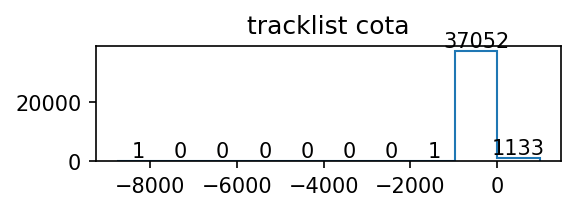

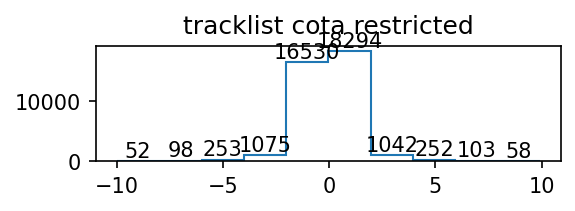

37601


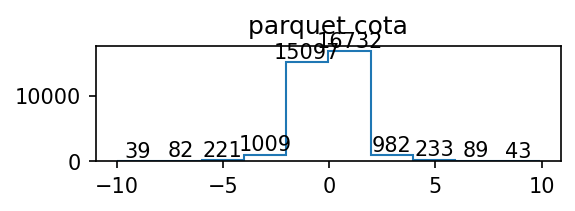

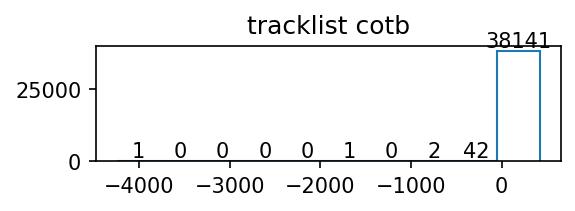

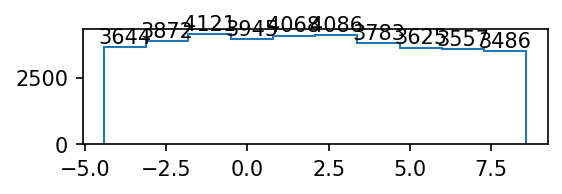

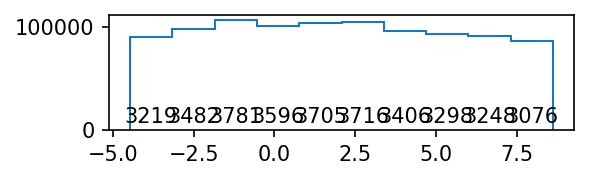

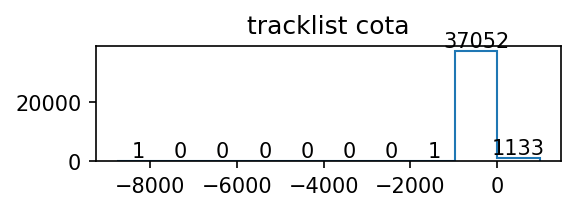

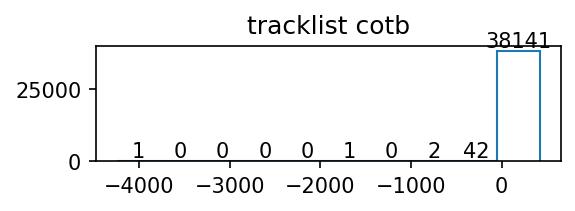

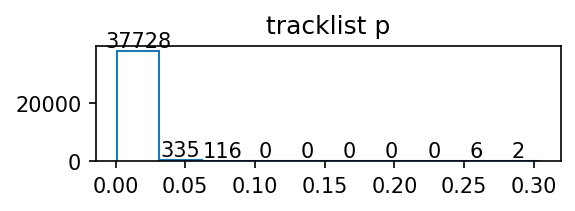

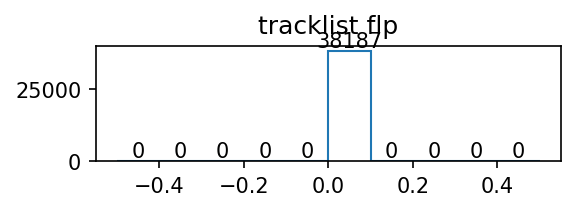

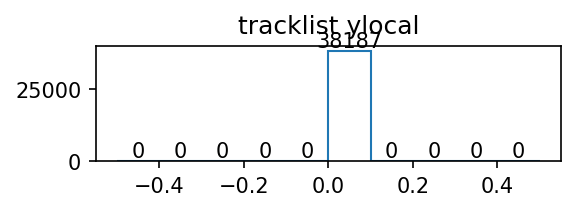

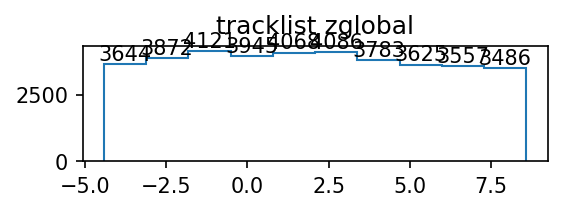

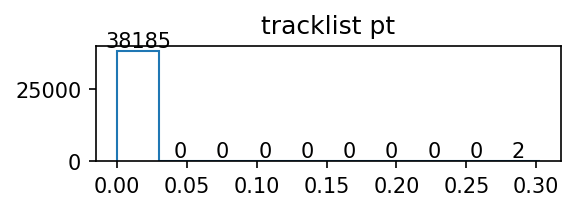

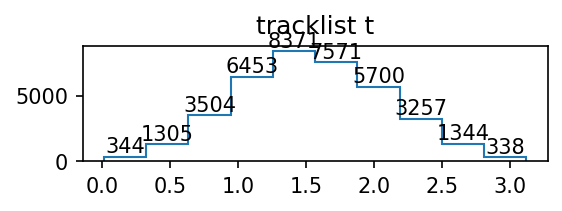

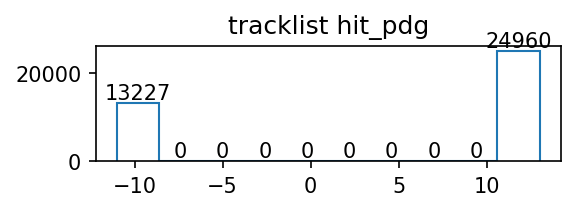

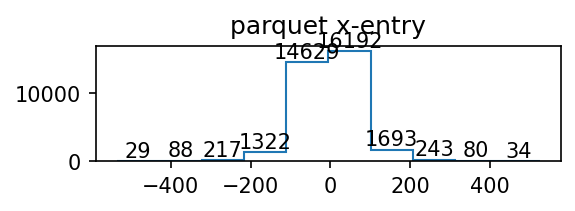

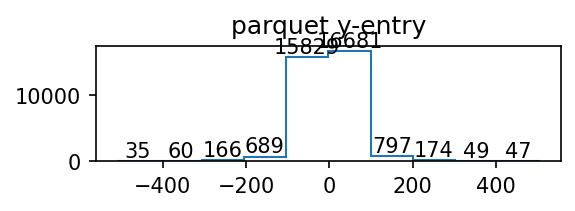

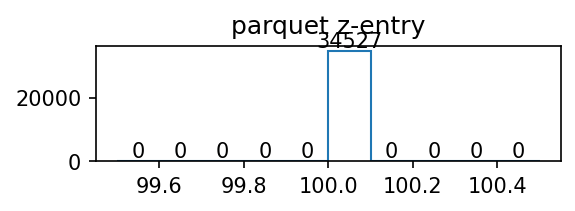

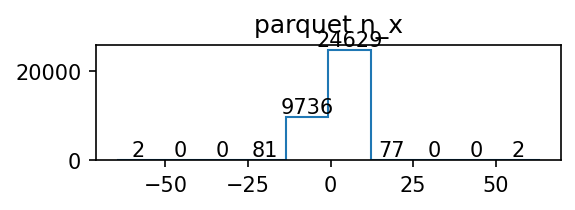

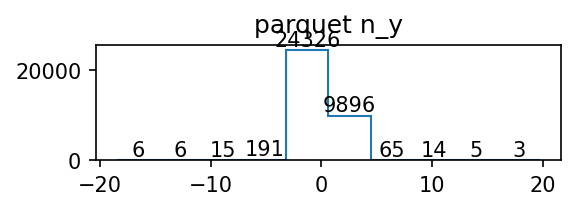

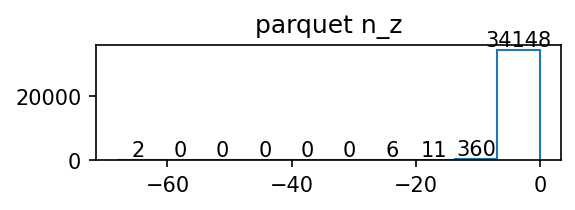

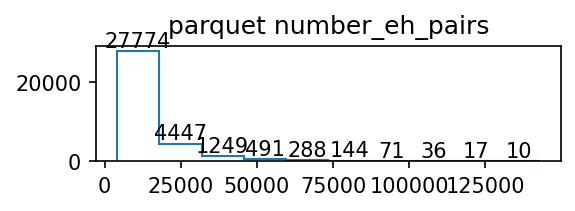

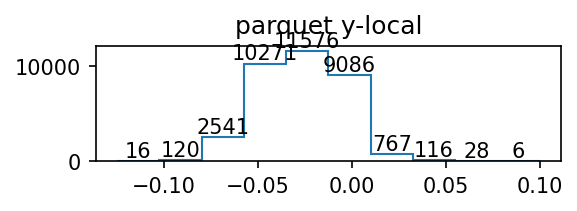

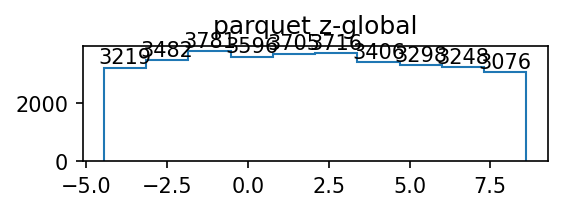

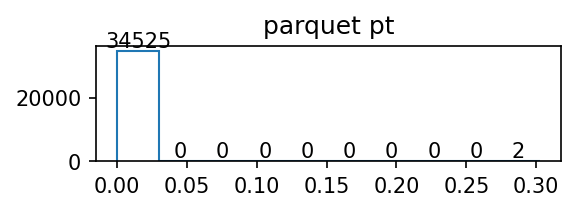

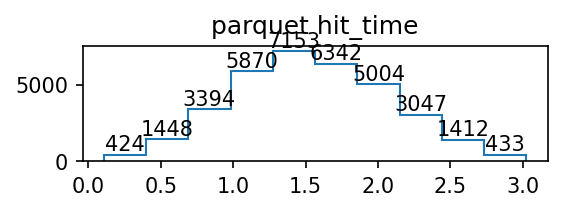

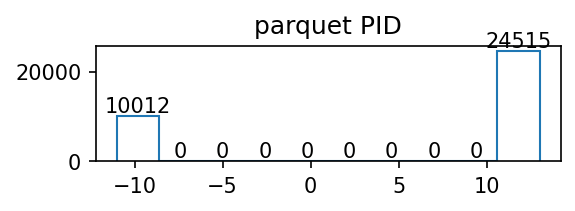

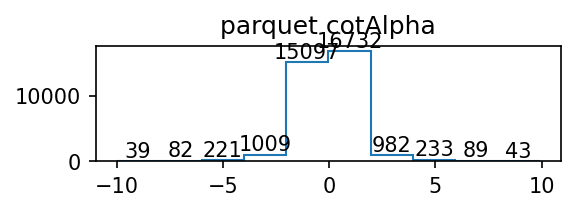

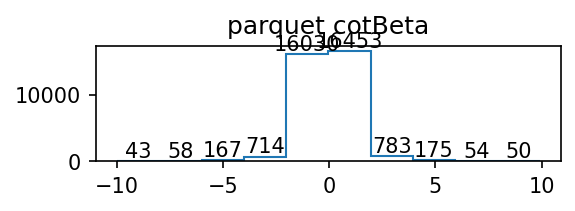

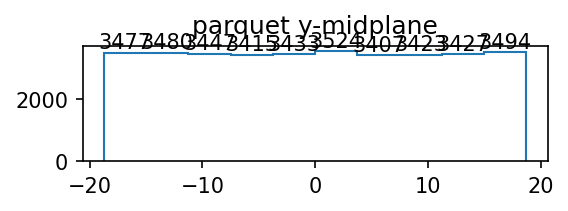

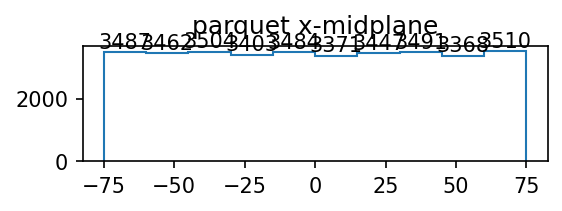

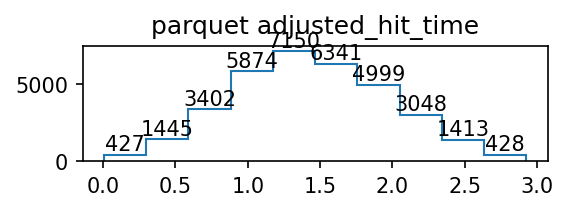

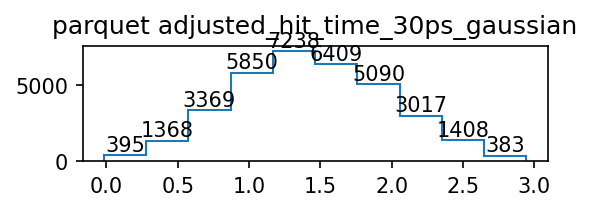

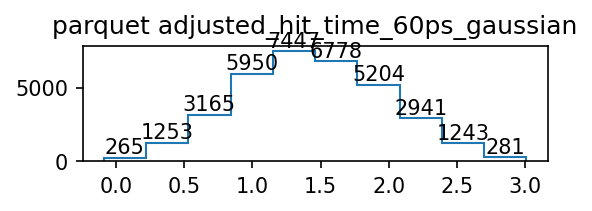

In [94]:
def plotHisto(arr,bins=None,postScale=1,title=""):
    plt.figure(figsize=(4,1))
    if bins==None:
        hist, bin_edges = np.histogram(arr)
    else:
        hist, bin_edges = np.histogram(arr,bins=bins)
    plt.stairs(hist*postScale,bin_edges)
    for i in range(len(hist)):
        # Calculate the x-coordinate for the center of the bar
        bin_center = (bin_edges[i] + bin_edges[i+1]) / 2
        # Place the text slightly above the top of the bar
        plt.text(bin_center, hist[i], int(hist[i]), ha='center', va='bottom')
    plt.title(title)
    plt.show()
    return hist,bin_edges
# hist,bin_edges = plotHisto(trackData["cota"],bins=100)
# print(hist)
print(np.where(trackData["cotb"]<-1000))
print(trackData["cotb"][(trackData["cotb"]>800)])
print(trackData["cota"][(trackData["cotb"]>800)])
plotHisto(trackData["cota"],title="tracklist cota")
plotHisto(trackData["cota"][np.logical_and(trackData["cota"]>-10,trackData["cota"]<10)],title="tracklist cota restricted")
print(np.size(trackData["cota"][np.logical_and(np.logical_and(trackData["cota"]>-10,trackData["cota"]<10),np.logical_and(trackData["cotb"]<10,trackData["cotb"]>-10))]))
plotHisto(truthbib["cotAlpha"],title="parquet cota")
plotHisto(trackData["cotb"],title="tracklist cotb")
plotHisto(trackData["zglobal"])
plotHisto(truthbib["z-global"],postScale=28)
for key in trackData.keys():
    plotHisto(trackData[key],title=f"tracklist {key}")
for key in truthbib.keys():
    plotHisto(truthbib[key],title=f"parquet {key}")

In [95]:
print(np.where(truthbib["pt"]>0.57))

(array([], dtype=int64),)


In [96]:
def get_charge_center(cluster):
    charge = np.zeros(13)
    pixelNo = np.arange(0,13) 
    for i in range(13):
        charge[i] = np.sum(cluster[i])

    centery = int(np.round(np.sum(charge*pixelNo)/np.sum(charge)))

    clusterTest = cluster.T
    charge = np.zeros(21)
    pixelNo = np.arange(0,21) 
    for i in range(21):
        charge[i] = np.sum(clusterTest[i])

    centerx = int(np.round(np.sum(charge*pixelNo)/np.sum(charge)))

    return centerx, centery

In [105]:
cmap = mcolors.LinearSegmentedColormap.from_list("", ["white","red","darkred"])
colors = [(1,1,1),
          (252/256,80/256,76/256),
          (177/256,7/256,3/256)]
cmap = mcolors.LinearSegmentedColormap.from_list("", colors )
cmap = mcolors.LinearSegmentedColormap.from_list("", ["white","red","green","blue"] )

def plotSingleCluster(cluster):
    fig, ax = plt.subplots(figsize=(7,5),dpi=200)

    # Plot charge collected in each pixel
    datamin = cluster.min()
    datamax = cluster.max()
    im = ax.imshow(cluster, vmin=datamin, vmax=datamax, cmap=cmap, interpolation='nearest')
    centerx, centery = get_charge_center(cluster)
    # ax.hlines(y=centery,xmax=20,xmin=0)
    # ax.vlines(x=centerx,ymax=12, ymin=0)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='Number of eh pairs')
    ax.set_title("Charge collected by 4 ns")

    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    fig.colorbar(im, cax=cax, location='right',label='Number of eh pairs')

    # Draw grid on both
    ax.set_xlim(-0.5,20.5)
    ax.set_ylim(-0.5,12.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.5))
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    ax.grid(which="minor", color="grey", linestyle='-', linewidth=0.5,snap=False)
    
    plt.tight_layout(pad=3.5)
    fig.canvas.draw()

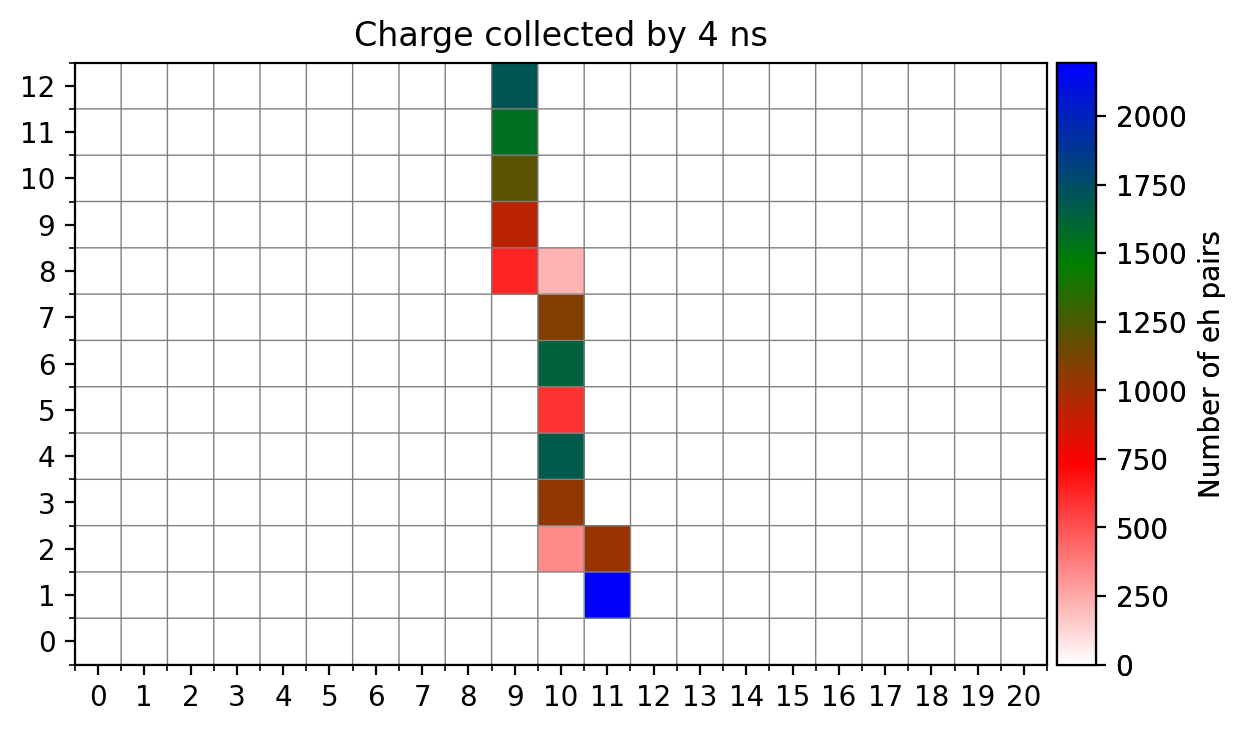

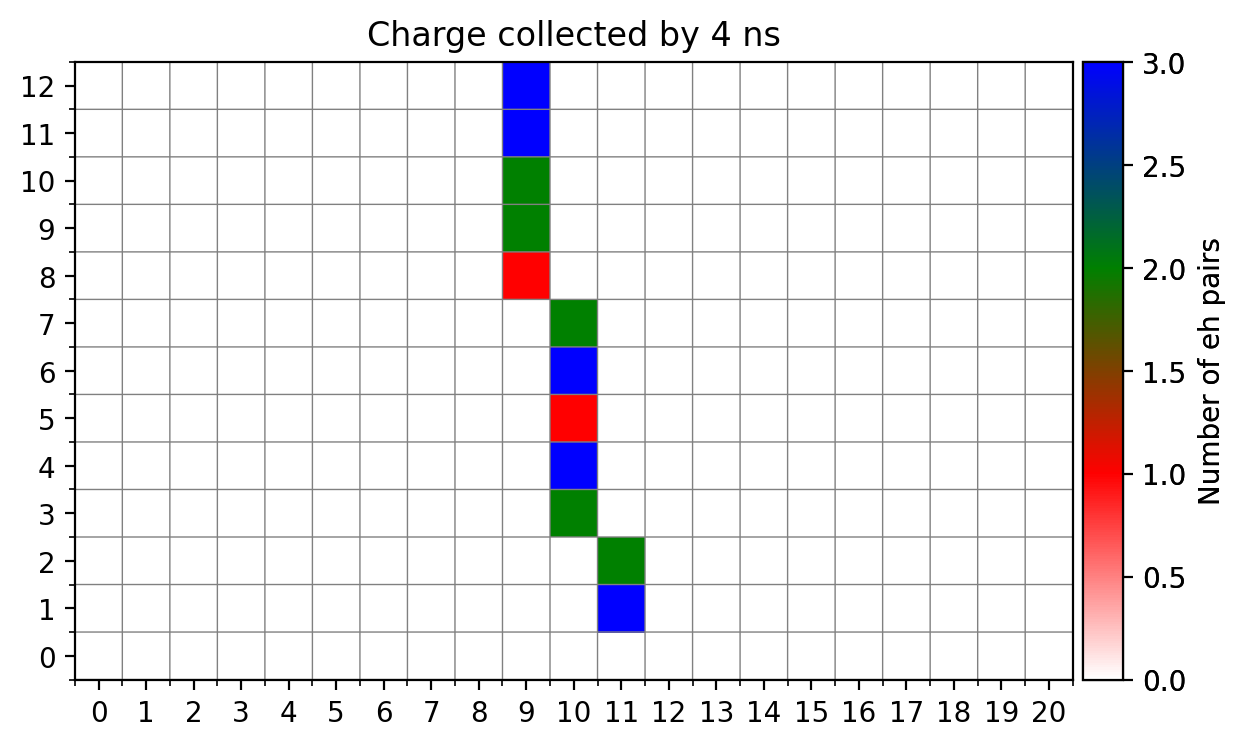

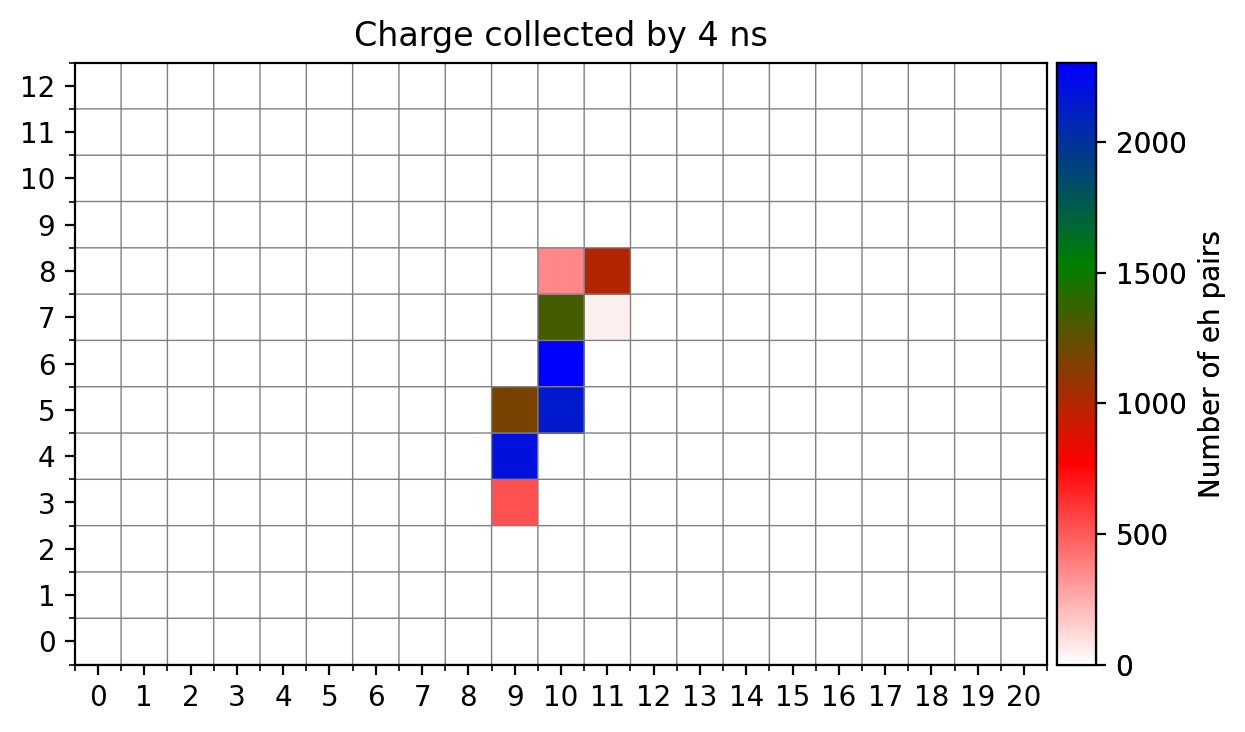

In [108]:
# plotSingleCluster(clustersBib[320])
plotSingleCluster(clustersBib[293])
quantizedCluster = clustersBib[293].copy()
quantizedCluster[quantizedCluster>1400] = 3
quantizedCluster[quantizedCluster>800] = 2
quantizedCluster[quantizedCluster>400] = 1
quantizedCluster[quantizedCluster>3] = 0
plotSingleCluster(quantizedCluster)
plotSingleCluster(clustersBib[26817])

In [99]:
truthbib['z-global']

0      1.34959
1      2.96027
2      3.39692
3     -4.15483
4      2.99962
        ...   
482    2.14349
483    3.93773
484    4.90888
485    4.89283
486    0.98985
Name: z-global, Length: 34527, dtype: float64

In [100]:
min(truthbib['z-global'])

-4.4635299999999996